# Implementasi Agglomerative Clustering di Python

## Dataset
 
**Mall Customers Dataset** berisi data pelanggan sebuah mall dengan fitur:
 
| Kolom | Deskripsi |
|---|---|
| `CustomerID` | ID unik pelanggan |
| `Gender` | Jenis kelamin (Male/Female) |
| `Age` | Usia pelanggan |
| `Annual Income (k$)` | Pendapatan tahunan (dalam ribu dollar) |
| `Spending Score (1-100)` | Skor belanja yang diberikan mall (1 = rendah, 100 = tinggi) |



> Download dataset: [Kaggle — Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

## Library

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

## Dataset

In [3]:
df = pd.read_csv('Mall_Customers (2).csv')

# Rename kolom agar lebih mudah diakses
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nStatistik Deskriptif:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (200, 5)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      200 non-null    int64
 1   Gender          200 non-null    str  
 2   Age             200 non-null    int64
 3   Annual_Income   200 non-null    int64
 4   Spending_Score  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

Statistik Deskriptif:
       CustomerID         Age  Annual_Income  Spending_Score
count  200.000000  200.000000     200.000000      200.000000
mean   100.500000   38.850000      60.560000       50.200000
std     57.879185   13.969007      26.264721       25.823522
min      1.000000   18.000000      15.000000        1.000000
25%     50.750000   28.750000      41.500000       34.750000
50%    100.500000   36.000000      61.500000       50.000000
75%    150.250000   49.000000      78.000000       73.000000
max    200.000000   7

## Preprocessing

In [8]:
# Encoding Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])
 
print("\nEncoding Gender:")
print(df[['Gender', 'Gender_encoded']].drop_duplicates())


Encoding Gender:
   Gender  Gender_encoded
0    Male               1
2  Female               0


In [9]:
X = df[['Gender_encoded', 'Age', 'Annual_Income', 'Spending_Score']]
 
print(f"\nFitur yang digunakan: {list(X.columns)}")
 
# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
print("\nSebelum scaling:")
print(X.describe().round(2))
print("\nSetelah scaling (mean ≈ 0, std ≈ 1):")
print(pd.DataFrame(X_scaled, columns=X.columns).describe().round(2))


Fitur yang digunakan: ['Gender_encoded', 'Age', 'Annual_Income', 'Spending_Score']

Sebelum scaling:
       Gender_encoded     Age  Annual_Income  Spending_Score
count          200.00  200.00         200.00          200.00
mean             0.44   38.85          60.56           50.20
std              0.50   13.97          26.26           25.82
min              0.00   18.00          15.00            1.00
25%              0.00   28.75          41.50           34.75
50%              0.00   36.00          61.50           50.00
75%              1.00   49.00          78.00           73.00
max              1.00   70.00         137.00           99.00

Setelah scaling (mean ≈ 0, std ≈ 1):
       Gender_encoded     Age  Annual_Income  Spending_Score
count          200.00  200.00         200.00          200.00
mean             0.00   -0.00          -0.00           -0.00
std              1.00    1.00           1.00            1.00
min             -0.89   -1.50          -1.74           -1.91
25%   

## Menentukan Jumlah Cluster

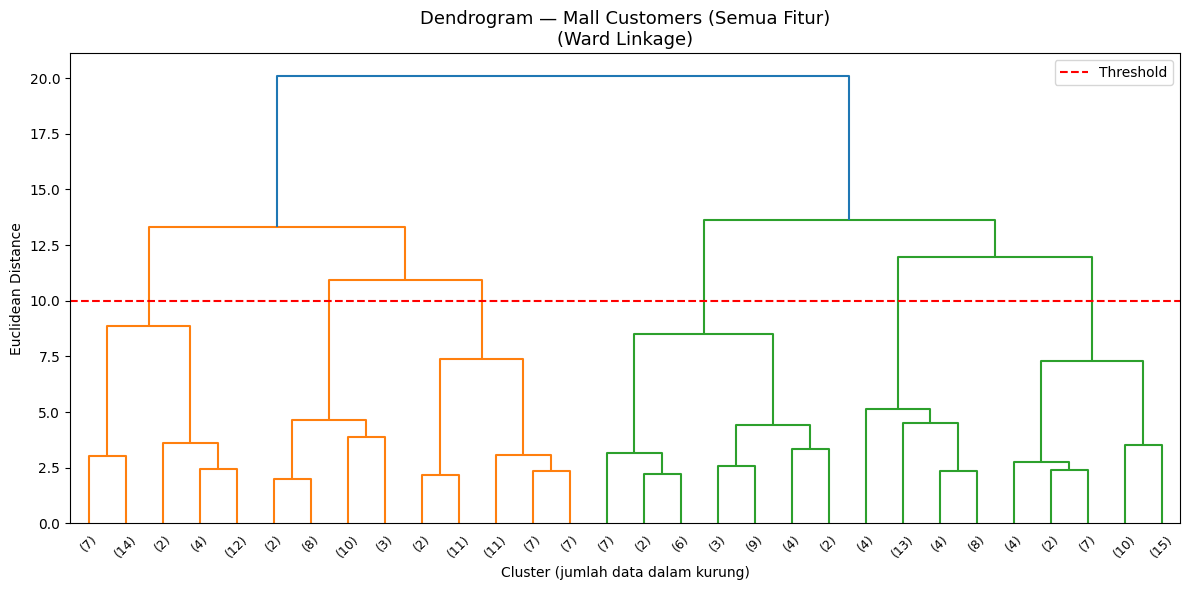

In [ ]:
linked = linkage(X_scaled, method='ward')
 
plt.figure(figsize=(12, 6))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    show_leaf_counts=True,
    leaf_rotation=45,
    leaf_font_size=9
)

plt.title('Dendrogram — Mall Customers (Semua Fitur)\n(Ward Linkage)', fontsize=13)
plt.xlabel('Cluster (jumlah data dalam kurung)')
plt.ylabel('Euclidean Distance')
plt.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Threshold')
plt.legend()
plt.tight_layout()
plt.show()

## Aglomerative

In [36]:
n_clusters = 4

AC = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',
    linkage='ward'
)

labels = AC.fit_predict(X_scaled)

# Tambahkan label ke dataframe
df['Cluster'] = labels

print("Jumlah anggota tiap cluster:")
print(df['Cluster'].value_counts().sort_index())

Jumlah anggota tiap cluster:
Cluster
0    67
1    61
2    33
3    39
Name: count, dtype: int64


## Evaluasi Hasil

In [37]:
sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)

print(f"Silhouette Score  : {sil:.4f}  (semakin mendekati 1 = semakin baik)")
print(f"Davies-Bouldin    : {dbi:.4f}  (semakin kecil = semakin baik)")

Silhouette Score  : 0.2632  (semakin mendekati 1 = semakin baik)
Davies-Bouldin    : 1.4020  (semakin kecil = semakin baik)


## Interpretasi Cluster

In [38]:
# Statistik rata-rata per cluster
cluster_summary = df.groupby('Cluster')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(1)
cluster_summary['Jumlah'] = df.groupby('Cluster').size()
print(cluster_summary)

          Age  Annual_Income  Spending_Score  Jumlah
Cluster                                             
0        52.7           46.7            40.4      67
1        26.1           43.8            59.0      61
2        41.5           89.1            16.2      33
3        32.7           86.5            82.1      39


In [39]:
cluster_summary = df.groupby('Cluster').agg(
    Jumlah        = ('CustomerID', 'count'),
    Rata_Age      = ('Age', 'mean'),
    Rata_Income   = ('Annual_Income', 'mean'),
    Rata_Spending = ('Spending_Score', 'mean'),
    Pria          = ('Gender_encoded', 'sum')
).round(1)
 
cluster_summary['Wanita'] = cluster_summary['Jumlah'] - cluster_summary['Pria']
 
print("\n" + "=" * 60)
print("RINGKASAN TIAP CLUSTER")
print("=" * 60)
print(cluster_summary.to_string())


RINGKASAN TIAP CLUSTER
         Jumlah  Rata_Age  Rata_Income  Rata_Spending  Pria  Wanita
Cluster                                                            
0            67      52.7         46.7           40.4    29      38
1            61      26.1         43.8           59.0    23      38
2            33      41.5         89.1           16.2    18      15
3            39      32.7         86.5           82.1    18      21


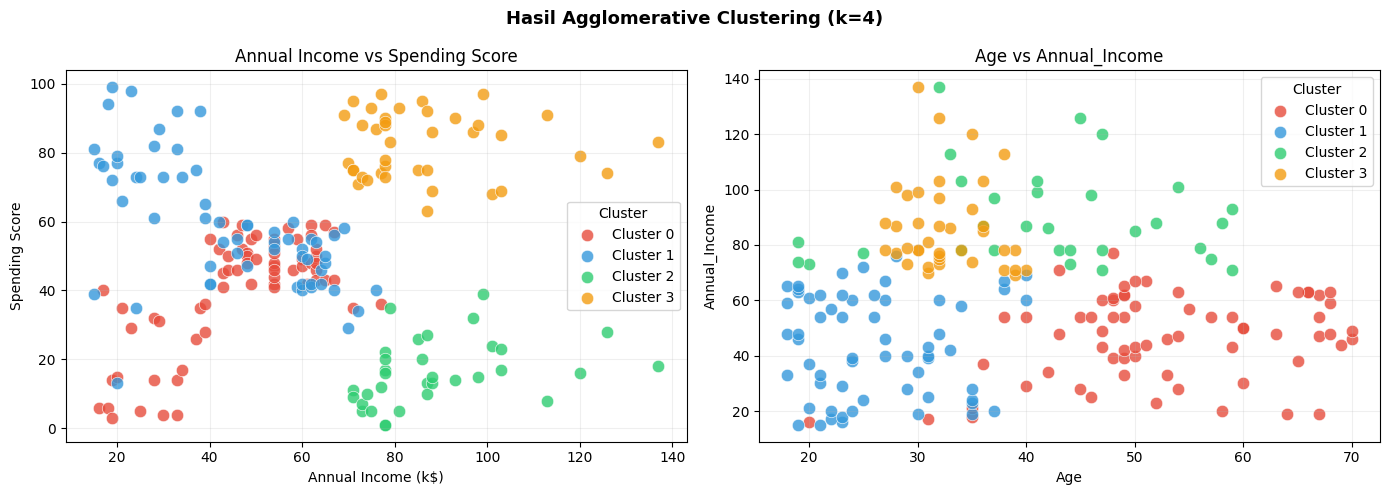

In [47]:
# Plot 1 — Annual Income vs Spending Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Hasil Agglomerative Clustering (k={n_clusters})', fontsize=13, fontweight='bold')
 
for i in range(n_clusters):
    mask = labels == i
    axes[0].scatter(
        df.loc[mask, 'Annual_Income'],
        df.loc[mask, 'Spending_Score'],
        c=colors[i], label=f'Cluster {i}',
        s=80, alpha=0.8, edgecolors='white', linewidths=0.5
    )
axes[0].set_title('Annual Income vs Spending Score')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')
axes[0].legend(title='Cluster')
axes[0].grid(alpha=0.2)
 
# Plot 2 — Age vs Spending Score
for i in range(n_clusters):
    mask = labels == i
    axes[1].scatter(
        df.loc[mask, 'Age'],
        df.loc[mask, 'Annual_Income'],
        c=colors[i], label=f'Cluster {i}',
        s=80, alpha=0.8, edgecolors='white', linewidths=0.5
    )
axes[1].set_title('Age vs Annual_Income')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Annual_Income')
axes[1].legend(title='Cluster')
axes[1].grid(alpha=0.2)
 
plt.tight_layout()
plt.show()

## Visualisasi Cluster dengan PCA

In [40]:
from sklearn.decomposition import PCA
 
# --- PCA 2 Komponen ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
 
explained = pca.explained_variance_ratio_ * 100
print("\n" + "=" * 50)
print("HASIL PCA")
print("=" * 50)
print(f"PC1 menjelaskan : {explained[0]:.2f}% variansi")
print(f"PC2 menjelaskan : {explained[1]:.2f}% variansi")
print(f"Total           : {sum(explained):.2f}% variansi")


HASIL PCA
PC1 menjelaskan : 33.69% variansi
PC2 menjelaskan : 26.23% variansi
Total           : 59.92% variansi


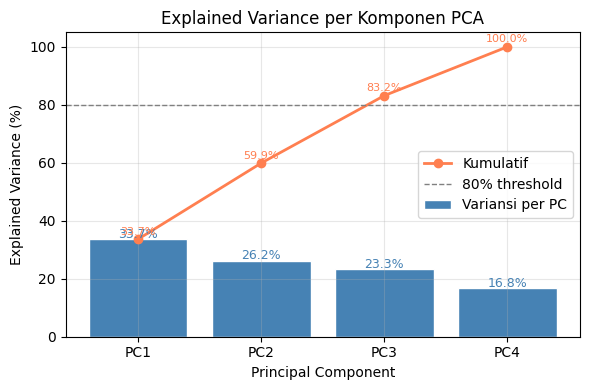

In [41]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
 
feature_names = ['Gender_encoded', 'Age', 'Annual_Income', 'Spending_Score']
 
# Explained Variance semua komponen
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_ * 100)
 
plt.figure(figsize=(6, 4))
plt.bar(range(1, 5), pca_full.explained_variance_ratio_ * 100,
        color='steelblue', edgecolor='white', label='Variansi per PC')
plt.plot(range(1, 5), cumulative_var, 'o-', color='coral',
         linewidth=2, label='Kumulatif')
plt.axhline(y=80, color='grey', linestyle='--', linewidth=1, label='80% threshold')
for i, (v, c) in enumerate(zip(pca_full.explained_variance_ratio_ * 100, cumulative_var)):
    plt.text(i + 1, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, color='steelblue')
    plt.text(i + 1, c + 1.5, f'{c:.1f}%', ha='center', fontsize=8, color='coral')
plt.title('Explained Variance per Komponen PCA')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.xticks(range(1, 5), ['PC1', 'PC2', 'PC3', 'PC4'])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)
 
explained3 = pca3.explained_variance_ratio_ * 100
total_var3  = sum(explained3)
 
print("\n" + "=" * 50)
print("HASIL PCA 3 KOMPONEN")
print("=" * 50)
print(f"PC1 menjelaskan : {explained3[0]:.2f}% variansi")
print(f"PC2 menjelaskan : {explained3[1]:.2f}% variansi")
print(f"PC3 menjelaskan : {explained3[2]:.2f}% variansi")
print(f"Total           : {total_var3:.2f}% variansi")
 
loadings3 = pd.DataFrame(
    pca3.components_.T,
    index=feature_names,
    columns=['PC1', 'PC2', 'PC3']
).round(4)
print("\nLoading tiap fitur terhadap PC1, PC2, PC3:")
print(loadings3.to_string())


HASIL PCA 3 KOMPONEN
PC1 menjelaskan : 33.69% variansi
PC2 menjelaskan : 26.23% variansi
PC3 menjelaskan : 23.26% variansi
Total           : 83.18% variansi

Loading tiap fitur terhadap PC1, PC2, PC3:
                   PC1     PC2     PC3
Gender_encoded  0.2343  0.6269  0.7430
Age             0.6879 -0.1037 -0.1224
Annual_Income  -0.0061  0.7653 -0.6437
Spending_Score -0.6869  0.1032  0.1366


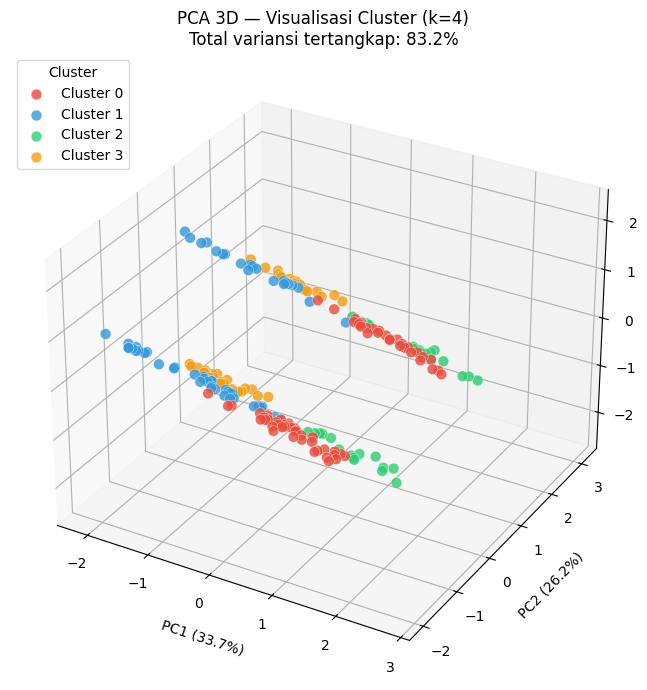

In [43]:
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')
 
for i in range(n_clusters):
    mask = labels == i
    ax.scatter(
        X_pca3[mask, 0],
        X_pca3[mask, 1],
        X_pca3[mask, 2],
        c=colors[i],
        label=f'Cluster {i}',
        s=60, alpha=0.8,
        edgecolors='white', linewidths=0.3
    )
 
ax.set_title(
    f'PCA 3D — Visualisasi Cluster (k={n_clusters})\n'
    f'Total variansi tertangkap: {total_var3:.1f}%',
    fontsize=12
)
ax.set_xlabel(f'PC1 ({explained3[0]:.1f}%)', labelpad=8)
ax.set_ylabel(f'PC2 ({explained3[1]:.1f}%)', labelpad=8)
ax.set_zlabel(f'PC3 ({explained3[2]:.1f}%)', labelpad=8)
ax.legend(title='Cluster', loc='upper left')
plt.tight_layout()
plt.show()

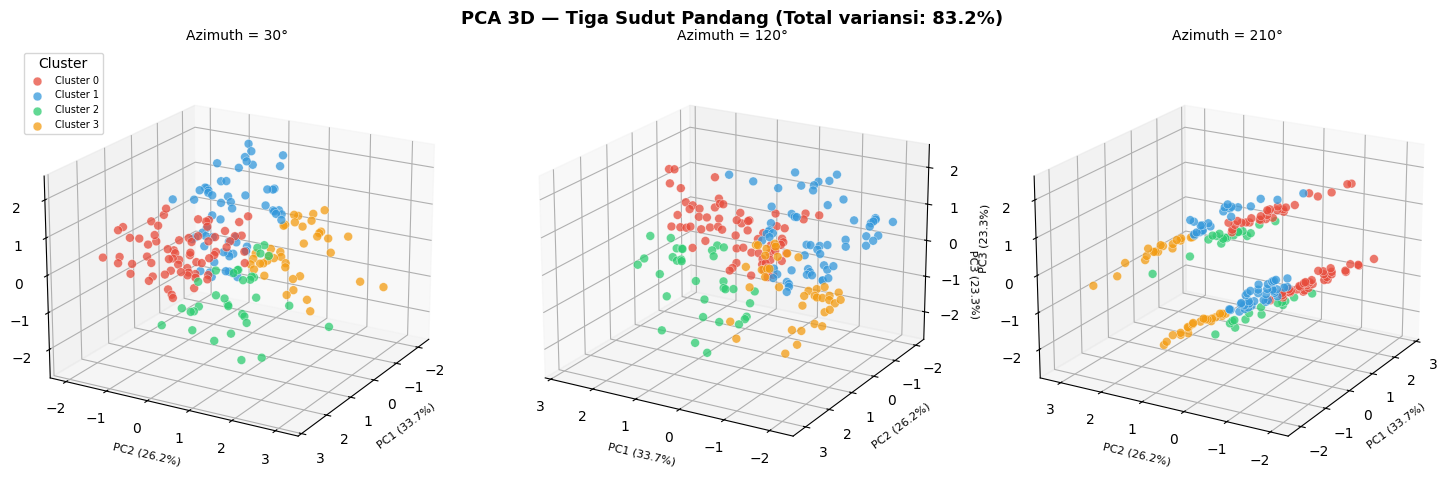

In [44]:
angles = [30, 120, 210]
fig = plt.figure(figsize=(15, 5))
fig.suptitle(
    f'PCA 3D — Tiga Sudut Pandang (Total variansi: {total_var3:.1f}%)',
    fontsize=13, fontweight='bold'
)
 
for idx, azim in enumerate(angles):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    for i in range(n_clusters):
        mask = labels == i
        ax.scatter(
            X_pca3[mask, 0],
            X_pca3[mask, 1],
            X_pca3[mask, 2],
            c=colors[i], label=f'Cluster {i}',
            s=40, alpha=0.75,
            edgecolors='white', linewidths=0.3
        )
    ax.set_title(f'Azimuth = {azim}°', fontsize=10)
    ax.set_xlabel(f'PC1 ({explained3[0]:.1f}%)', fontsize=8, labelpad=5)
    ax.set_ylabel(f'PC2 ({explained3[1]:.1f}%)', fontsize=8, labelpad=5)
    ax.set_zlabel(f'PC3 ({explained3[2]:.1f}%)', fontsize=8, labelpad=5)
    ax.view_init(elev=20, azim=azim)
    if idx == 0:
        ax.legend(title='Cluster', fontsize=7, loc='upper left')
 
plt.tight_layout()
plt.show()